In [1]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 10.8 MB/s eta 0:00:00


In [2]:
pip install yfinance

In [3]:
pip install statsmodels

In [43]:
# Importing Python lybraries

import yfinance as yf # Public yahooh finance API.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf, adfuller, q_stat
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from scipy.stats import normaltest, skew, kurtosis, chi2, norm
import scipy

from arch.univariate import ARX, GARCH, arch_model

# diasble warnings

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Importing time series from yahoo finance

# Microsoft
msft = yf.Ticker("MSFT") # Get the ticker for stock Microsoft
msft_hist = msft.history(period="10y") # get historical time series correspondig the ticker. 10y = ten years

# Apple
aapl = yf.Ticker("AAPL")
aapl_hist = aapl.history(period="10y")

# NVIDIA
nvda = yf.Ticker("NVDA")
nvda_hist = nvda.history(period="10y")

# S&P 500 (note the ticker symbol ^GSPC)
sp500 = yf.Ticker("^GSPC")
sp500_hist = sp500.history(period="10y")

# Optionally, print the first few rows of each
print("Microsoft\n", msft_hist.head(), "\n")
print("Apple\n", aapl_hist.head(), "\n")
print("NVIDIA\n", nvda_hist.head(), "\n")
print("S&P 500\n", sp500_hist.head(), "\n")

Microsoft
                                 Open       High        Low      Close  \
Date                                                                    
2015-06-04 00:00:00-04:00  40.571172  40.891994  40.059588  40.198322   
2015-06-05 00:00:00-04:00  40.154976  40.337064  39.747442  40.007568   
2015-06-08 00:00:00-04:00  40.146299  40.259022  39.600031  39.652058   
2015-06-09 00:00:00-04:00  39.678065  39.834141  39.417938  39.582687   
2015-06-10 00:00:00-04:00  39.704086  40.605861  39.617375  40.415100   

                             Volume  Dividends  Stock Splits  
Date                                                          
2015-06-04 00:00:00-04:00  27745500        0.0           0.0  
2015-06-05 00:00:00-04:00  25438100        0.0           0.0  
2015-06-08 00:00:00-04:00  22121600        0.0           0.0  
2015-06-09 00:00:00-04:00  24406100        0.0           0.0  
2015-06-10 00:00:00-04:00  28417400        0.0           0.0   

Apple
                            

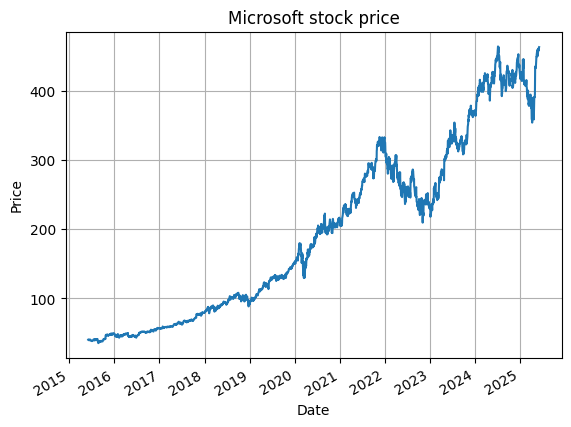

In [7]:
msft_hist['Close'].plot()
plt.grid()
plt.title('Microsoft stock price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

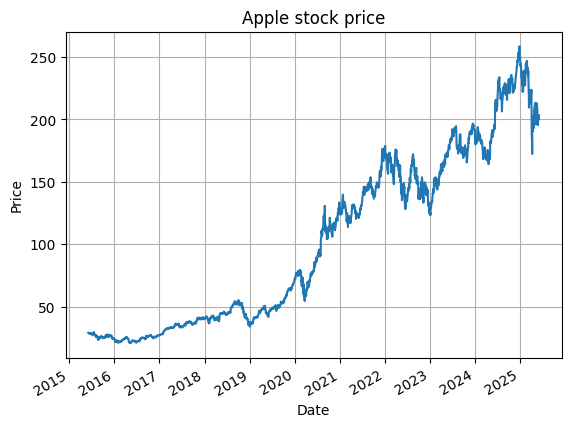

In [8]:
aapl_hist['Close'].plot()
plt.grid()
plt.title('Apple stock price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

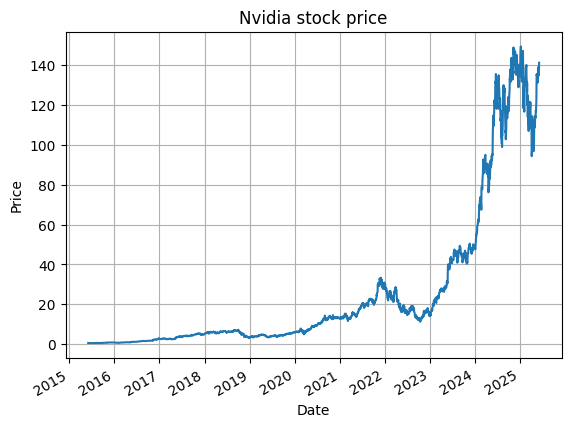

In [9]:
nvda_hist['Close'].plot()
plt.grid()
plt.title('Nvidia stock price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

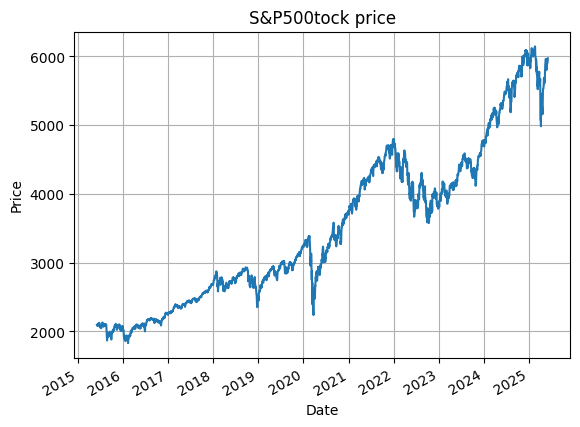

In [10]:
sp500_hist['Close'].plot()
plt.grid()
plt.title('S&P500tock price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

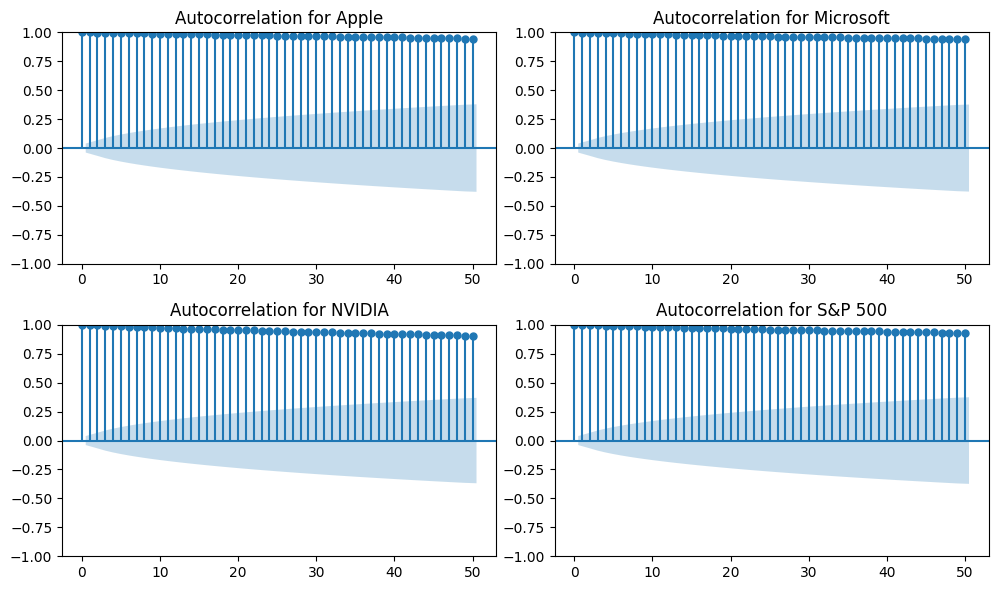

In [19]:
# Let's plot for serial autocorrelation for each time series

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Apple
plot_acf(aapl_hist['Close'], lags=50, ax=axs[0, 0])
axs[0, 0].set_title("Autocorrelation for Apple")

# Microsoft
plot_acf(msft_hist['Close'], lags=50, ax=axs[0, 1])
axs[0, 1].set_title("Autocorrelation for Microsoft")

# NVIDIA
plot_acf(nvda_hist['Close'], lags=50, ax=axs[1, 0])
axs[1, 0].set_title("Autocorrelation for NVIDIA")

# S&P 500
plot_acf(sp500_hist['Close'], lags=50, ax=axs[1, 1])
axs[1, 1].set_title("Autocorrelation for S&P 500")

# Adjust layout
plt.tight_layout()
plt.show()

In [13]:
# Let's compute the log-returns for each series

aapl_log_returns = np.log(aapl_hist['Close'] / aapl_hist['Close'].shift(1)).dropna()
sp500_log_returns = np.log(sp500_hist['Close'] / sp500_hist['Close'].shift(1)).dropna()
nvda_log_returns = np.log(nvda_hist['Close'] / nvda_hist['Close'].shift(1)).dropna()
msft_log_returns = np.log(msft_hist['Close'] / msft_hist['Close'].shift(1)).dropna()

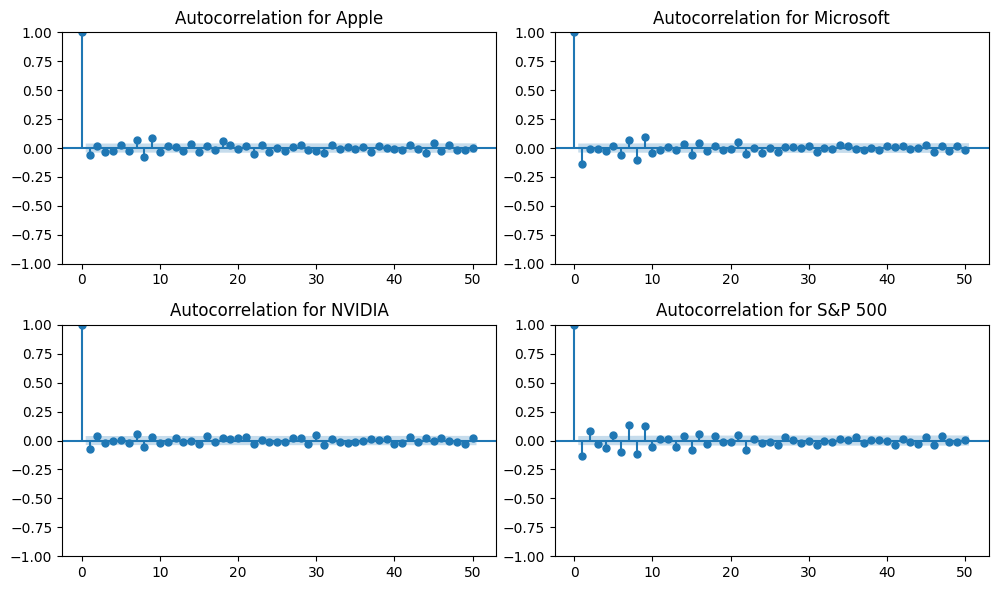

In [21]:
# Let's plot for serial autocorrelation for each time series of the log returns

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Apple
plot_acf(aapl_log_returns, lags=50, ax=axs[0, 0])
axs[0, 0].set_title("Autocorrelation for Apple")

# Microsoft
plot_acf(msft_log_returns, lags=50, ax=axs[0, 1])
axs[0, 1].set_title("Autocorrelation for Microsoft")

# NVIDIA
plot_acf(nvda_log_returns, lags=50, ax=axs[1, 0])
axs[1, 0].set_title("Autocorrelation for NVIDIA")

# S&P 500
plot_acf(sp500_log_returns, lags=50, ax=axs[1, 1])
axs[1, 1].set_title("Autocorrelation for S&P 500")

# Adjust layout
plt.tight_layout()
plt.show()

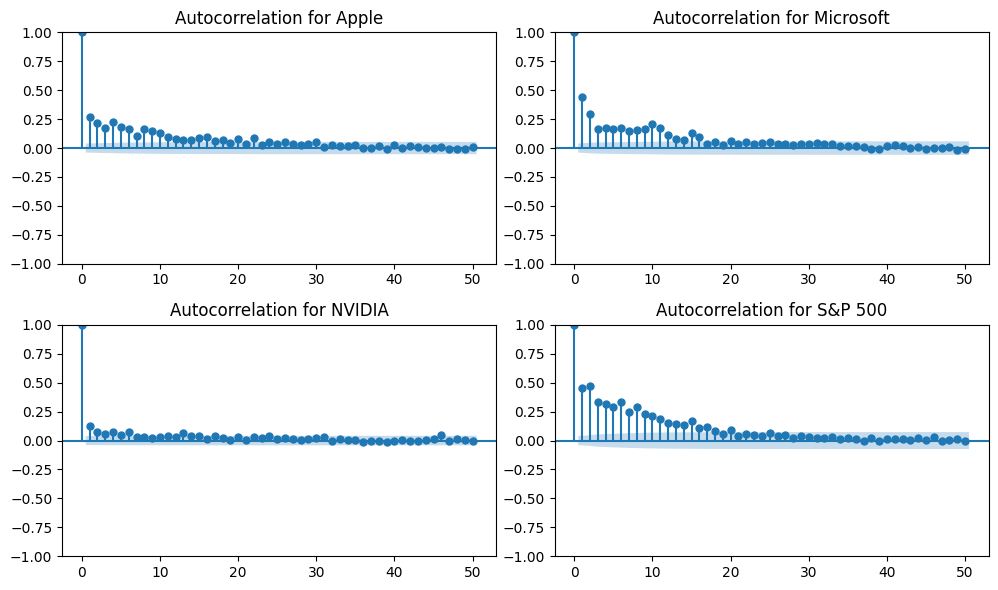

In [22]:
# Let's plot for serial autocorrelation for each time series of the squared log returns

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Apple
plot_acf(aapl_log_returns**2, lags=50, ax=axs[0, 0])
axs[0, 0].set_title("Autocorrelation for Apple")

# Microsoft
plot_acf(msft_log_returns**2, lags=50, ax=axs[0, 1])
axs[0, 1].set_title("Autocorrelation for Microsoft")

# NVIDIA
plot_acf(nvda_log_returns**2, lags=50, ax=axs[1, 0])
axs[1, 0].set_title("Autocorrelation for NVIDIA")

# S&P 500
plot_acf(sp500_log_returns**2, lags=50, ax=axs[1, 1])
axs[1, 1].set_title("Autocorrelation for S&P 500")

# Adjust layout
plt.tight_layout()
plt.show()

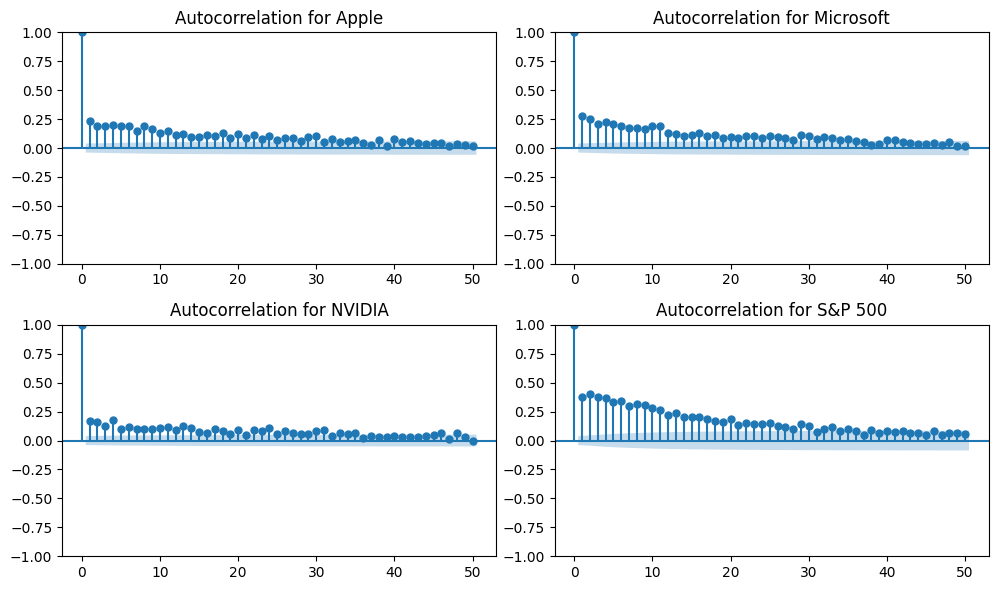

In [23]:
# Let's plot for serial autocorrelation for each time series of the absolute value of log returns

# Create 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Apple
plot_acf(np.abs(aapl_log_returns), lags=50, ax=axs[0, 0])
axs[0, 0].set_title("Autocorrelation for Apple")

# Microsoft
plot_acf(np.abs(msft_log_returns), lags=50, ax=axs[0, 1])
axs[0, 1].set_title("Autocorrelation for Microsoft")

# NVIDIA
plot_acf(np.abs(nvda_log_returns), lags=50, ax=axs[1, 0])
axs[1, 0].set_title("Autocorrelation for NVIDIA")

# S&P 500
plot_acf(np.abs(sp500_log_returns), lags=50, ax=axs[1, 1])
axs[1, 1].set_title("Autocorrelation for S&P 500")

# Adjust layout
plt.tight_layout()
plt.show()

In [30]:
res_norm_test_sp500 = normaltest(sp500_log_returns.values)
res_norm_test_aapl = normaltest(aapl_log_returns.values)
res_norm_test_nvda = normaltest(nvda_log_returns.values)
res_norm_test_msft = normaltest(msft_log_returns.values)

print(f"Normality test for S&P 500: statistic {res_norm_test_sp500.statistic:.4f}, pvalue {res_norm_test_sp500.pvalue:.4f}")
print(f"Normality test for Apple: statistic {res_norm_test_aapl.statistic:.4f}, pvalue {res_norm_test_aapl.pvalue:.4f}")
print(f"Normality test for NVIDIA: statistic {res_norm_test_nvda.statistic:.4f}, pvalue {res_norm_test_nvda.pvalue:.4f}")
print(f"Normality test for Microsoft: statistic {res_norm_test_msft.statistic:.4f}, pvalue {res_norm_test_msft.pvalue:.4f}")

Normality test for S&P 500: statistic 710.9281, pvalue 0.0000
Normality test for Apple: statistic 342.8776, pvalue 0.0000
Normality test for NVIDIA: statistic 357.3396, pvalue 0.0000
Normality test for Microsoft: statistic 389.0288, pvalue 0.0000


In [32]:
# Let's fit a GARCH model with no exogenous variables

aapl_model = arch_model(y=aapl_log_returns, mean='ARX', vol='GARCH', p=1, q=1)
aapl_res = aapl_model.fit(disp='off')
print(aapl_res.summary)

<bound method ARCHModelResult.summary of                            AR - GARCH Model Results                           
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6719.70
Distribution:                  Normal   AIC:                          -13431.4
Method:            Maximum Likelihood   BIC:                          -13408.1
                                        No. Observations:                 2514
Date:                Wed, Jun 04 2025   Df Residuals:                     2513
Time:                        10:34:41   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const      1.7265

In [51]:
aapl_res.params

,params
Const,0.001726
omega,0.000007
alpha[1],0.100000
beta[1],0.880000


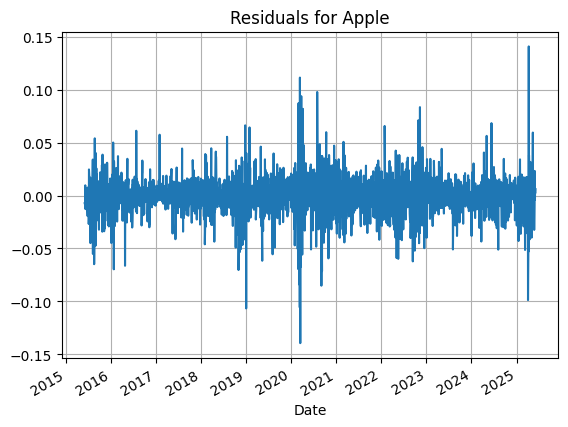

In [35]:
# Let's extract the residuals

aapl_res.resid.plot()
plt.grid()
plt.title('Residuals for Apple')
plt.show()

In [46]:
# Let's test if the residuals are Gaussian

res_norm_test_aapl_res = normaltest(aapl_res.resid.values)
print(f"Normality test for Apple: statistic {res_norm_test_aapl_res.statistic:.4f}, pvalue {res_norm_test_aapl_res.pvalue:.4f}")

Normality test for Apple: statistic 342.8776, pvalue 0.0000


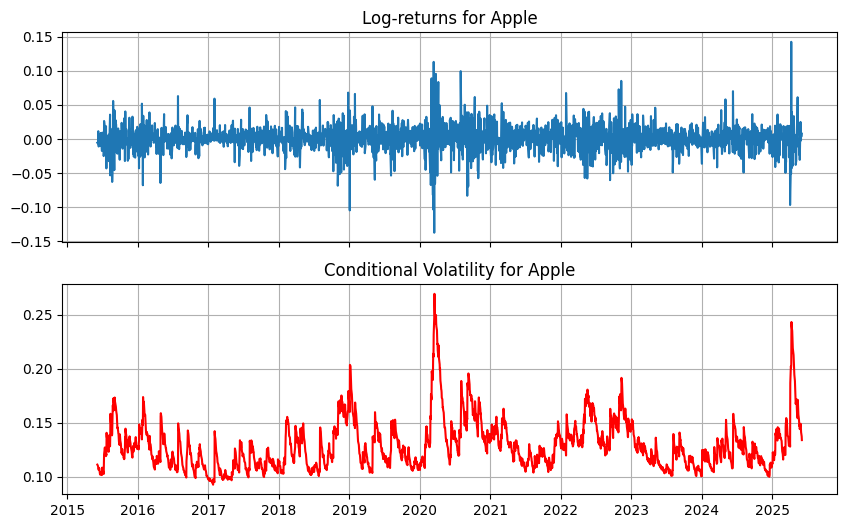

In [41]:
# Let's extract the volatility and make it in subplot with log-returns a vol

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot log-returns
axs[0].plot(aapl_log_returns)
axs[0].set_title("Log-returns for Apple")
axs[0].grid(True)

# Plot conditional volatility
axs[1].plot(np.sqrt(aapl_res.conditional_volatility), 'r')
axs[1].set_title("Conditional Volatility for Apple")
axs[1].grid(True)

plt.show()


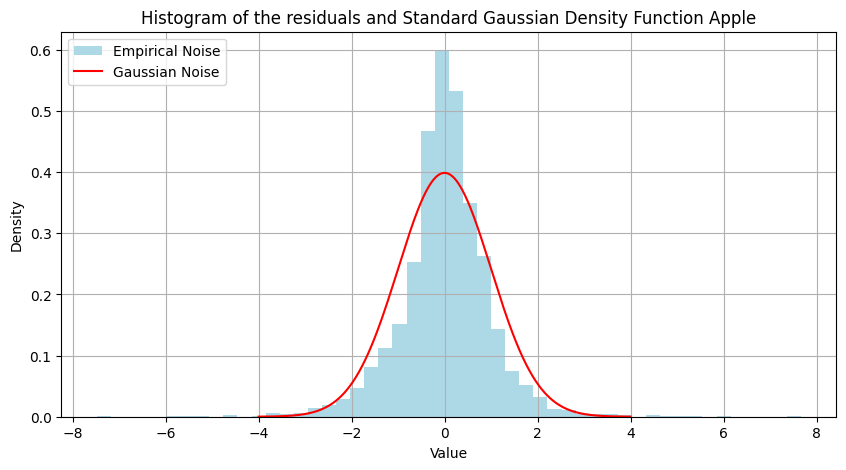

In [45]:
plt.figure(figsize=(10,5))
plt.hist((aapl_res.resid-np.mean(aapl_res.resid))/np.std(aapl_res.resid) , bins=50, density=True, color='lightblue', label='Empirical Noise')
pdf = scipy.stats.norm.pdf(np.linspace(-4, 4, len(aapl_res.resid)), loc=0, scale=1)
plt.plot(np.linspace(-4, 4, len(aapl_res.resid)), pdf, color='r', label='Gaussian Noise')
plt.grid()
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of the residuals and Standard Gaussian Density Function Apple')
plt.legend(loc='upper left')
plt.show()

In [54]:
# Let's now perform a 1 step ahead forecast

aapl_forecast = aapl_res.forecast(horizon=1, reindex=False)
print(aapl_forecast.mean)
print(aapl_forecast.variance)

                                h.1
Date                               
2025-06-03 00:00:00-04:00  0.001726
                                h.1
Date                               
2025-06-03 00:00:00-04:00  0.000293


In [59]:
# Let's now compute the value at risk

cond_mean = aapl_forecast.mean.values
cond_var = aapl_forecast.variance.values
cond_vol = np.sqrt(cond_var)
q = aapl_model.distribution.ppf([0.01, 0.025, 0.05])


# Compute VaR at 1%, 2.5%, and 5%
VaR_1 = cond_mean + cond_vol * q[0]
VaR_25 = cond_mean + cond_vol * q[1]
VaR_5 = cond_mean + cond_vol * q[2]

print(f"Value at Risk (1%): {VaR_1[0, 0]:.4f}")
print(f"Value at Risk (2.5%): {VaR_25[0, 0]:.4f}")
print(f"Value at Risk (5%): {VaR_5[0, 0]:.4f}")

Value at Risk (1%): -0.0381
Value at Risk (2.5%): -0.0318
Value at Risk (5%): -0.0264


**Let's perform a minimum variance asset allocation**

In [81]:
def minimum_variance_obj_fun(weights_array, correlation_matrix):
    # correlation_matrix = numpy array or matrix (no pandas object)
    # weights_array = numpy array or matrix (no pandas object)
    return 0.5 * (weights_array @ correlation_matrix @ weights_array.T)

def fit_weights(weights_array, correlation_matrix):

    A = np.ones(len(weights_array))

    linear_constraint = scipy.optimize.LinearConstraint(A, 1, 1)

    res = scipy.optimize.minimize(minimum_variance_obj_fun, weights_array, args=(correlation_matrix), method='SLSQP', constraints=[linear_constraint], options={'verbose': 1})

    return res.x, res.fun

In [65]:
# Let's fit a GARCH model with no exogenous variables for MIcrosoft

msft_model = arch_model(y=msft_log_returns, mean='ARX', vol='GARCH', p=1, q=1)
msft_res = msft_model.fit(disp='off')
print(msft_res.summary)

msft_forecast = msft_res.forecast(horizon=1, reindex=False)
print(msft_forecast.mean)
print(msft_forecast.variance)

<bound method ARCHModelResult.summary of                            AR - GARCH Model Results                           
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6926.56
Distribution:                  Normal   AIC:                          -13845.1
Method:            Maximum Likelihood   BIC:                          -13821.8
                                        No. Observations:                 2514
Date:                Wed, Jun 04 2025   Df Residuals:                     2513
Time:                        13:09:59   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
Const      1.2477

In [66]:
# Let's compute the correlation between the residuals of Apple and Microsoft GARCH models

correlation_matrix = np.corrcoef(aapl_res.resid, msft_res.resid)
print(correlation_matrix)

[[1.         0.69134857]
 [0.69134857 1.        ]]


In [79]:
# Now we compute the actual covariance matrix with the forecasts of the vol from the GARCH model

v = np.hstack((np.sqrt(aapl_forecast.variance.values), np.sqrt(msft_forecast.variance.values))).T
print(v)
print()
print(v@v.T)
print()
print(v**2)
print()
print(v[0]*v[1])
print()
COV = correlation_matrix * (v@v.T)
print(COV)

[[0.01712458]
 [0.01124416]]

[[0.00029325 0.00019255]
 [0.00019255 0.00012643]]

[[0.00029325]
 [0.00012643]]

[0.00019255]

[[0.00029325 0.00013312]
 [0.00013312 0.00012643]]


In [74]:
eigval, eigvec = np.linalg.eig(COV)

print(eigval)
print()
print(eigvec)

[2.13839294e-04 3.90231832e-05]

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [83]:
w0 = np.array([.1, .1])
w_fit = fit_weights(w0, COV)
print(w_fit)

(array([0.49999166, 0.50000834]), np.float64(8.573969997206134e-05))


**Non Gaussian Case**

In [33]:
# Let's fit a GARCH model with no exogenous variables and student-distribution

aapl_model2 = arch_model(y=aapl_log_returns, mean='ARX', vol='GARCH', p=1, q=1, dist='t')
aapl_res2 = aapl_model2.fit(disp='off')
print(aapl_res2.summary)

<bound method ARCHModelResult.summary of                               AR - GARCH Model Results                              
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                              AR   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                4673.35
Distribution:      Standardized Student's t   AIC:                          -9336.70
Method:                  Maximum Likelihood   BIC:                          -9307.56
                                              No. Observations:                 2514
Date:                      Wed, Jun 04 2025   Df Residuals:                     2513
Time:                              10:35:46   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------

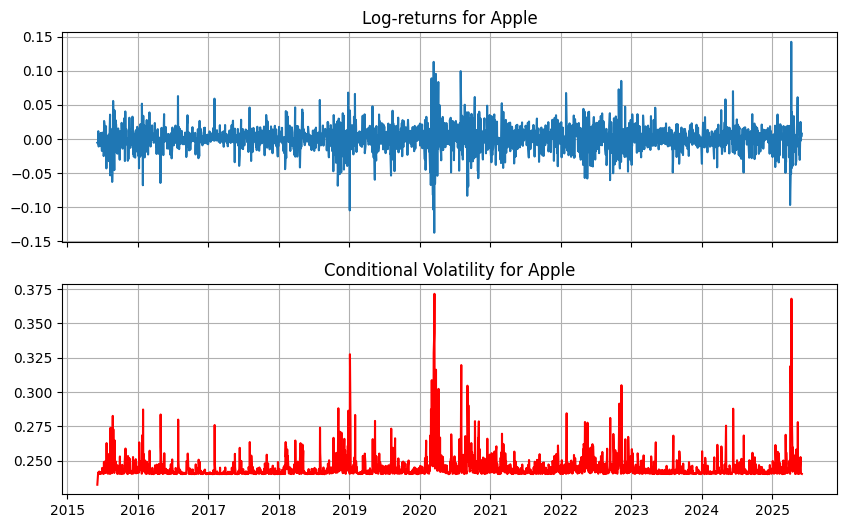

In [42]:
# Let's extract the volatility and make it in subplot with log-returns a vol

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot log-returns
axs[0].plot(aapl_log_returns)
axs[0].set_title("Log-returns for Apple")
axs[0].grid(True)

# Plot conditional volatility
axs[1].plot(np.sqrt(aapl_res2.conditional_volatility), 'r')
axs[1].set_title("Conditional Volatility for Apple")
axs[1].grid(True)

plt.show()

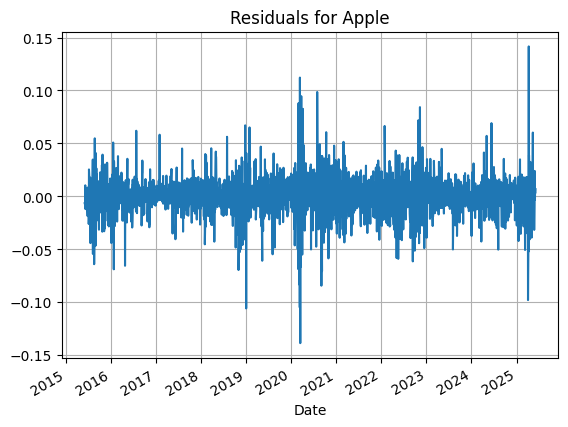

In [61]:
# Let's extract the residuals

aapl_res2.resid.plot()
plt.grid()
plt.title('Residuals for Apple')
plt.show()

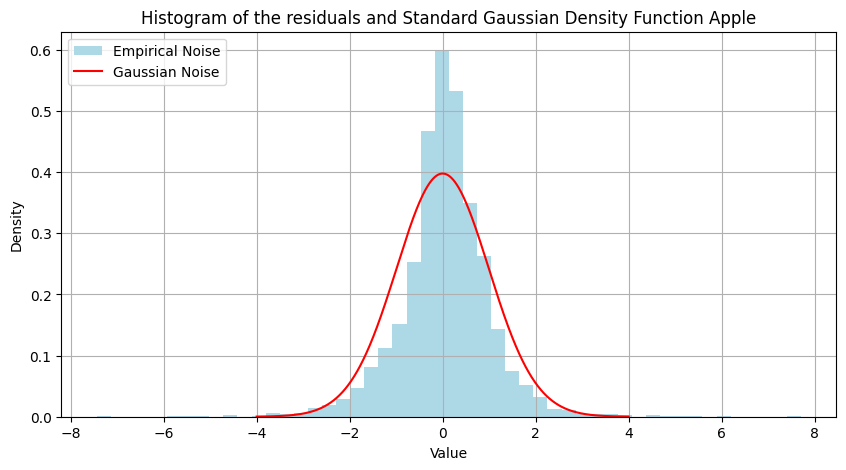

In [50]:
plt.figure(figsize=(10,5))
plt.hist((aapl_res2.resid-np.mean(aapl_res.resid))/np.std(aapl_res.resid) , bins=50, density=True, color='lightblue', label='Empirical Noise')
pdf = scipy.stats.t.pdf(np.linspace(-4, 4, len(aapl_res.resid)), loc=0, scale=1, df=aapl_res2.params.loc['nu'])
plt.plot(np.linspace(-4, 4, len(aapl_res.resid)), pdf, color='r', label='Gaussian Noise')
plt.grid()
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of the residuals and Standard Gaussian Density Function Apple')
plt.legend(loc='upper left')
plt.show()

In [48]:
aapl_res2.params

,params
Const,0.000966
omega,0.002791
alpha[1],0.729919
beta[1],0.161769
nu,93.567517


In [55]:
aapl_forecast2 = aapl_res2.forecast(horizon=1, reindex=False)
print(aapl_forecast2.mean)
print(aapl_forecast2.variance)

                                h.1
Date                               
2025-06-03 00:00:00-04:00  0.000966
                                h.1
Date                               
2025-06-03 00:00:00-04:00  0.003365


In [60]:
# Let's now compute the value at risk

cond_mean = aapl_forecast2.mean.values
cond_var = aapl_forecast2.variance.values
cond_vol = np.sqrt(cond_var)
q = aapl_model2.distribution.ppf([0.01, 0.025, 0.05], aapl_res2.params.iloc[-1] )


# Compute VaR at 1%, 2.5%, and 5%
VaR_1 = cond_mean + cond_vol * q[0]
VaR_25 = cond_mean + cond_vol * q[1]
VaR_5 = cond_mean + cond_vol * q[2]

print(f"Value at Risk (1%): {VaR_1[0, 0]:.4f}")
print(f"Value at Risk (2.5%): {VaR_25[0, 0]:.4f}")
print(f"Value at Risk (5%): {VaR_5[0, 0]:.4f}")

Value at Risk (1%): -0.1349
Value at Risk (2.5%): -0.1130
Value at Risk (5%): -0.0944
